In [ ]:
import os

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import metrics
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    GroupKFold,
    GroupShuffleSplit,
    KFold,
    ShuffleSplit,
    StratifiedKFold,
    StratifiedShuffleSplit,
    cross_val_score,
    cross_val_predict,
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.3)

N_JOBS = -1
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Кросс-валидация  (cross-validation)

В простом случае предполагается, что у нас есть данные для обучения **train set** и данные для тестирования **test set**. Таргеты для тестовых данных считаются неизвестными, поэтому их нельзя использовать для обучения модели. Главная цель валидации &mdash; оценить, какое качество модель способна показать на тестовых данных.

Ранее мы уже познакомились со случаным лесом, который зависит от большого количества различных гиперпараметров. Для подбора оптимальных параметров использовался `GridSearchCV`, который в частности использует кросс-валидацию. В этом ноутбуке познакомимся с ней подробнее и рассмотрим различные стратегии.

## 1. Валидация на отложенной выборке (holdout validation)

При оценке качества модели нельзя использовать данные, которые использовались для ее обучения, т.к. при таком подходе мы не сможем оценить адекватность модели на новых данных и контролировать переобучение. Для решения данной проблемы существуют подходы, использующие понятие **отложенной выборки**: $X_{val}$, $Y_{val}$. Отложенной выборкой называют размеченные данные, которые мы не используем при обучении модели.

В рассматриваемом нами случае ответы на тестовых данных неизвестны, а потому отложенную выборку мы можем сформировать лишь из обучающих данных. Такую выборку обычно называют валидационным множеством (validation set или development set).

В scikit-learn разбиение на обучающую и тестовую выборки можно легко получить с помощью функции `train_test_split`.

Рассмотрим на примере задачи классификации ирисов.

In [ ]:
# Загружаем датасет
data_full = load_iris()
X_iris, y_iris = data_full.data, data_full.target
print('Shape: {}'.format(X_iris.shape))

Shape: (150, 4)


Применим функцию `train_test_split` для разбиения данных.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    # *arrays: принимает индексируемые объекты с совпадающей shape[0].
    # Например: list, np.array, pd.DataFrame.
    X_iris, y_iris,
    test_size=0.4,  # доля данных, которые берем в тестовую выборку
    shuffle=True,  # перемешивает данные в случайном порядке
    random_state=0,  # фиксируем случайность
    stratify=None  # если не None, то сохраняет доли классов при разбиении
)

print("Shape of train data: {} {}".format(X_train.shape, y_train.shape))
print("Shape of test data: {} {}".format(X_test.shape, y_test.shape))

Shape of train data: (90, 4) (90,)
Shape of test data: (60, 4) (60,)


Посмотрим на распределение по классам.

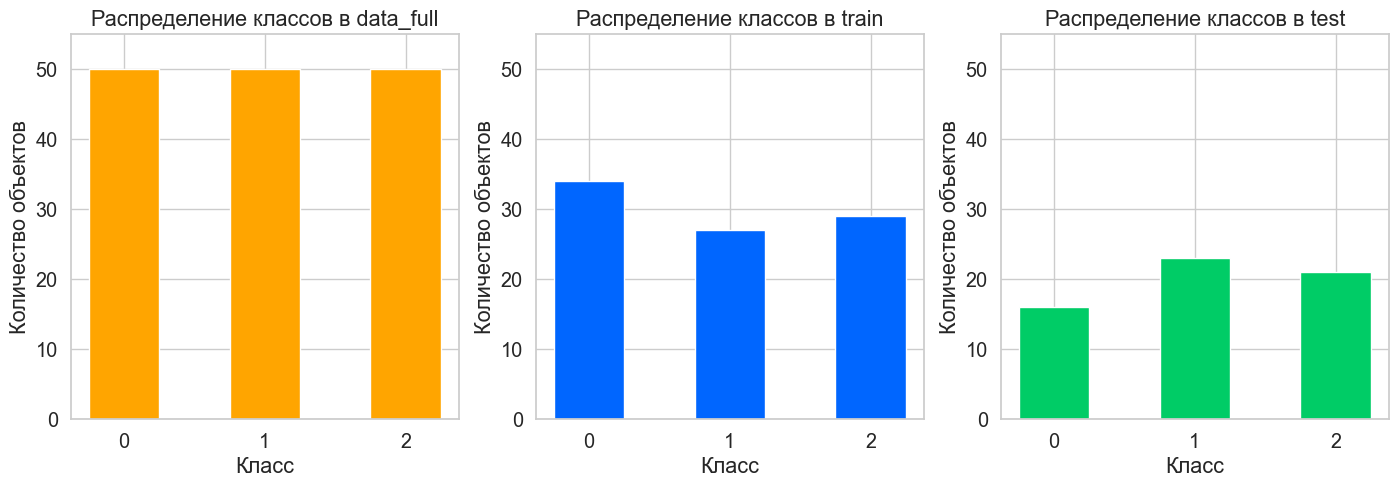

In [ ]:
plt.figure(figsize=(17,5))
split_cases = [y_iris, y_train, y_test]
colors = ['orange', '#0066FF', '#00CC66']
labels = ['Распределение классов в data_full',
          'Распределение классов в train',
          'Распределение классов в test']
for i in range(3):
    plt.subplot(1, 3, i + 1)
    values, counts = np.unique(split_cases[i], return_counts=True)
    plt.bar(values, counts, width=0.5, color=colors[i])
    plt.ylim(0, 55)
    plt.xticks([0, 1, 2])
    plt.xlabel('Класс')
    plt.ylabel('Количество объектов')
    plt.title(labels[i])
plt.show()

Видим, что распределение классов в обучающей и тестовой выборках отличаются. Теперь попробуем сделать разбиение с `stratify = data_full.target`. Стратификация &mdash; стратегия кросс-валидации, при которой в обучающей и тестовой выборке сохраняется одинаковое распределение целевой переменной, такое же, как во всем датасете. Зачем нужна стратификация узнаем чуть позже.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    # *arrays: принимает индексируемые объекты с совпадающей shape[0].
    # Например: list, np.array, pd.DataFrame.
    X_iris, data_full.target,
    test_size=0.4, # доля данных, которые берем в тестовую выборку
    random_state=0, # фиксируем случайность
    shuffle=True, # перемешивает данные в случайном порядке
    # сохраняем доли классов при разбиении как в таргете
    stratify=y_iris
)

И также посмотрим на распределение по классам.

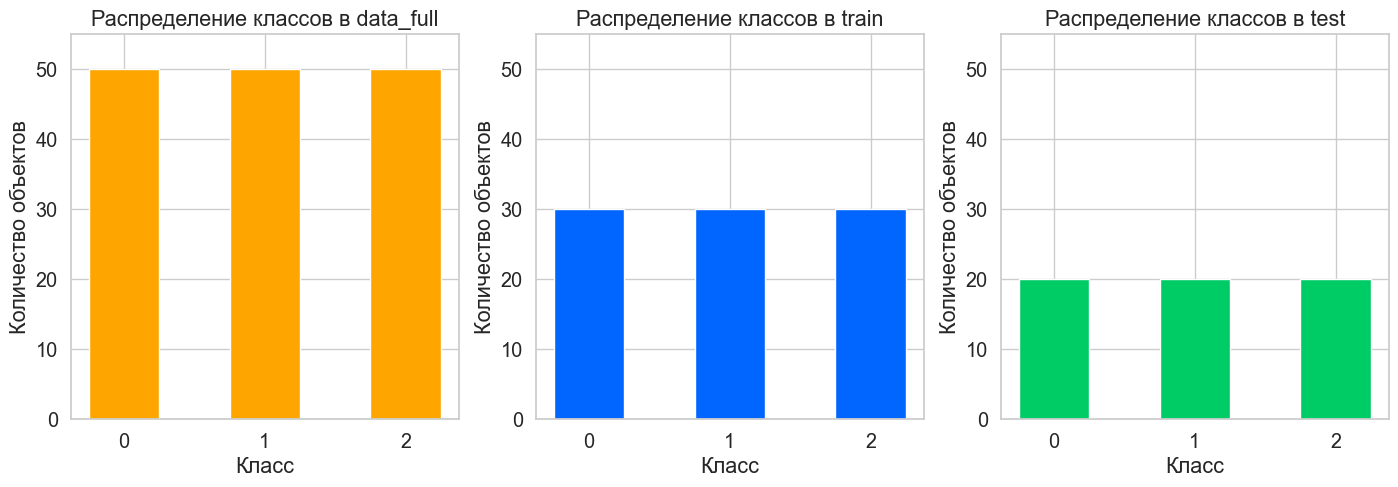

In [ ]:
plt.figure(figsize = (17,5))
split_cases = [y_iris, y_train, y_test]
colors = ['orange', '#0066FF', '#00CC66']
labels = ['Распределение классов в data_full',
          'Распределение классов в train',
          'Распределение классов в test']
for i in range(3):
    plt.subplot(1, 3, i + 1)
    values, counts = np.unique(split_cases[i], return_counts=True)
    plt.bar(values, counts, width=0.5, color=colors[i])
    plt.ylim(0, 55)
    plt.xticks([0, 1, 2])
    plt.xlabel('Класс')
    plt.ylabel('Количество объектов')
    plt.title(labels[i])
plt.show()

Видим, что после разбиения с `stratify = data_full.target` распределения классов в train и test не отличаются.

Подведем итог для метода отложенной выборки.

**Достоинства:**
* Быстрый для оценки качества модели. При использовании данной техники разбиения данных для оценки качества модели происходит одна процедура обучения на обучающей выборке, после чего качество модели оценивается на тестовых данных.

**Недостатки:**
* Результат сильно зависит от способа разбиения. Объекты в train и test могут получиться из разных распределений, если `stratify = False`.
* При обучении модели на обучающей выборке валидационная выборка не используется, то есть мы не задействуем все доступные данные для обучения.
* При оптимизации значения метрики на валидационном множестве модель немного переобучается под него. Таким образом, значение метрики качества на новых данных не будет соответствовать значению метрики на тестовом множестве.

## 2. Стратегии кросс-валидации


### 2.1. k-Fold Cross Validation

**k-Fold Кросс-валидация** &mdash; это метод оценки качества модели, при котором обучающая выборка делится на $k$ частей, или **фолдов**. После чего для каждого из $k$ фолдов проделывается следующая процедура:
* модель обучается на остальных $k-1$ фолдах, которые вместе формируют обучающую выборку для данной итерации,
* обученная модель оценивается на $k$-ом фолде.

Таким образом мы получаем $k$ оценок качества. Итоговая метрика считается как среднее полученных оценок. Ниже представлена визуализация рассматриваемой стратегии кросс-валидации для пяти фолдов.

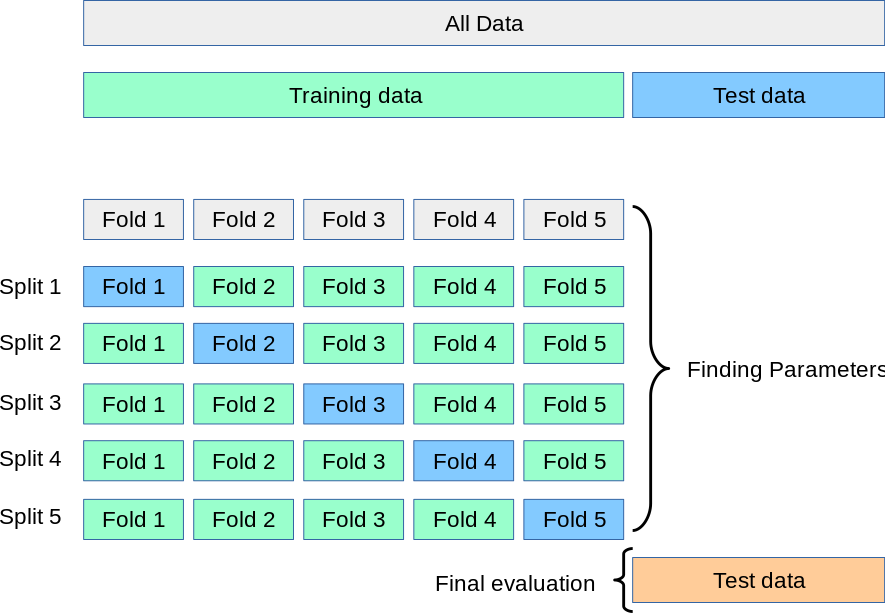

Для примера рассмотрим датасет [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) из предыдущего ноутбука про случайный лес.

Признаки, содержащиеся в датасете:
* `Time` &mdash; время, прошедшее между данной транзакцией и первой транзкцией из датасета;
* `V1-V28` &mdash; анонимизированные признаки для сохранения конфиденциальности;
* `Amount` &mdash; сумма транзакции;
* `Class` &mdash; целевой класс, является ли транзакция мошеннической.


In [ ]:
# Скачиваем датасет из kaggle
path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
data_full = pd.read_csv(os.path.join(path, 'creditcard.csv'))
data_full.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Разделяем признаки и таргет.

In [ ]:
X_cards = data_full.iloc[:, 1:30]
y_cards = data_full['Class']

При помощи функции [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html) можно получить предсказания модели для всех объектов выборки, но с учётом разбиения на фолды. То есть каждый объект предсказывается моделью, которая не обучалась на нём, что исключает утечку информации. Например, это удобно, если нужно построить матрицу ошибок или ROC-кривую на всей выборке.

Построим confusion matrix для задачи выявления мошеннических транзакций.

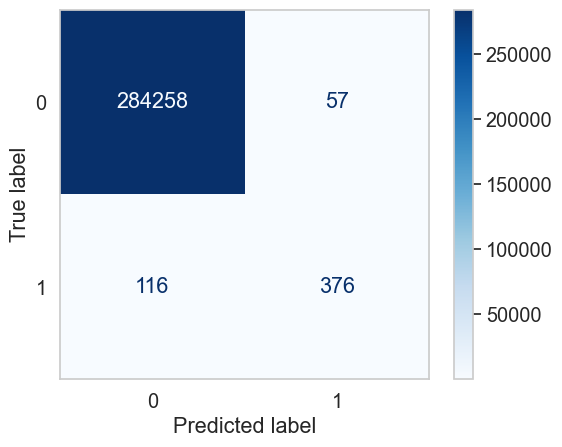

In [ ]:
model = RandomForestClassifier(random_state=RANDOM_STATE)

# Получаем предсказания по всей выборке (через кросс-валидацию)
y_pred = cross_val_predict(
    estimator=model,    # Модель, предсказания которой хотим получить
    X=X_cards,          # Данные для обучения (без целевой переменной)
    y=y_cards,          # Значения целевой переменной
    cv=5,               # Количество фолдов (разбиений данных)
    n_jobs=N_JOBS,      # Количество ядер для вычислений, -1 - использовать все ядра
)

# Строим confusion matrix
cm = confusion_matrix(y_cards, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.grid(False)
plt.show()


А при помощи функции [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) можем сразу получить значение выбранной метрики на каждом фолде без необходимости считать их вручную.

В качестве примера применим ее к случайному лесу и посчитаем точность на каждом фолде.

In [ ]:
model = RandomForestClassifier()
scores = cross_val_score(
    estimator=model,    # Модель, качество которой хотим оценить
    X=X_cards,          # Данные для обучения (не содержат целевую переменную)
    y=y_cards,          # Значения целевой переменной
    cv=5,               # Количество фолдов
    # Метрика качества, она будет максимизироваться
    scoring=metrics.make_scorer(metrics.fbeta_score, beta=2),
    n_jobs=N_JOBS,      # Количество ядер для вычислений, -1 - использование всех ядер
)
print(f'Значения f2-меры на разных фолдах: {scores.round(3)}')
print(f'Среднее f2-меры: {scores.mean():.3f}')

Значения f2-меры на разных фолдах: [0.829 0.814 0.698 0.826 0.738]
Среднее f2-меры: 0.781


Видим, что значения $f_2$-меры довольно сильно отличаются: от 0.811 до 0.877. Таким образом, с помощью кросс-валидации мы, во-первых, понимаем, что наши замеры качества в данном случае довольно шумные, а во-вторых, после усреднения сможем уменьшить шум в отличие от отложенной валидации.

*Полезно знать*:  
* В sklearn подразумевается максимизация метрики качества `scoring` вне зависимости от задачи. Поэтому в случае решения задачи регрессии, где нужно минимизировать $MSE$, следует указывать аргумент `scoring='neg_mean_squared_error'`. Приставка `neg` отзначает, что будет оптимизироваться $\left(-1\right) \cdot MSE$.
* Функция [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html) &mdash; позволяет задать сразу несколько метрик для подсчета качества модели. Возвращает значения данных метрик для каждой итерации кросс-валидации в виде словаря.

Выше мы рассмотрели функцию `cross_val_score`, которая имеет аргумент `cv` (CV &mdash; сокращение от Cross-Validation). По умолчанию данный аргумент использует стратегию кросс-валидации KFold, но ему можно передавать и другие стратегии кросс-валидации. Рассмотрим аналогичный способ использования KFold кросс-валидации, который на практике является более гибким.

Задаем стратегию кросс-валидации KFold.

In [ ]:
kfold = KFold(
    n_splits=2,       # Количество фолдов
    shuffle=False,    # Перемешиваем ли данные перед разбиением
)
kfold

KFold(n_splits=2, random_state=None, shuffle=False)

В sklearn объекты классов, которые соответствуют стратегиям кросс-валидации, обычно имеют два метода:
* `get_n_splits` &mdash; возвращает количество итераций, которое необходимо для заданной стратегии кросс-валидации;
* `split` &mdash; возвращает генератор индексов для разбиения данных на train и test.

*Замечание.* У этого класса нет никакого механизма стратификации.

In [ ]:
kfold.get_n_splits()

2

In [ ]:
kfold.split(X=X_cards)

<generator object _BaseKFold.split at 0x128394ca0>

Приведем пример, демонстрирующий работу метода `split`.

In [ ]:
data = np.array([[81, 27], [26, 45], [83, 64], [25, 98]])
data

array([[81, 27],
       [26, 45],
       [83, 64],
       [25, 98]])

In [ ]:
for train_index, val_index in kfold.split(data):
    print("TRAIN:", train_index, "VAL:", val_index)

TRAIN: [2 3] VAL: [0 1]
TRAIN: [0 1] VAL: [2 3]


Аргумент `cv` функции `cross_val_score` помимо количества фолдов, может также принимать на вход стратегию кросс-валидации. Как и ранее на выходе функции получаем значения метрик для каждой итерации кросс-валидации.

In [ ]:
kfold = KFold(
    n_splits=5,         # Количество фолдов
    shuffle=True,        # Перемешиваем ли данные перед разбиением
    random_state=RANDOM_STATE,    # Фиксируем рандом, который появляется из-за shuffle
)
scores = cross_val_score(
    estimator=model,    # Модель, качество которой хотим оценить
    X=X_cards,          # Данные для обучения (не содержат целевую переменную)
    y=y_cards,          # Значения целевой переменной
    cv=kfold,           # Стратегия кросс-валидации
    # Метрика качества, она будет максимизироваться
    scoring=metrics.make_scorer(metrics.fbeta_score, beta=2),
    n_jobs=N_JOBS,      # Количество ядер для вычислений, -1 - использование всех ядер
)
print(f'Значения f2-меры на разных фолдах: {scores.round(3)}')
print(f'Среднее f2-меры: {scores.mean():.3f}')

Значения f2-меры на разных фолдах: [0.817 0.861 0.763 0.804 0.848]
Среднее f2-меры: 0.819


Визуальная интерпретация k-Fold кросс-валидации (для параметра `shuffle=False`):

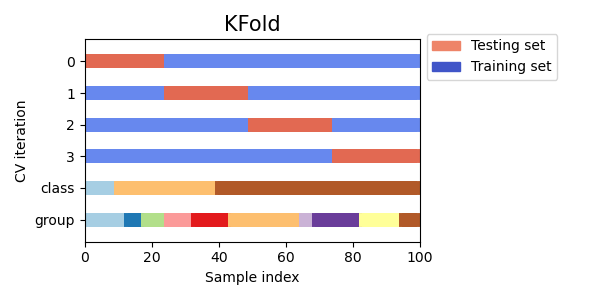

На данном графике представлена 4-Fold CV. Каждую горизонтальную полосу стоит понимать как одну и ту же выборку из 100 элементов. По горизонтальной оси показан номер элемента выборки. По вертикальной оси сверху отложены номера фолдов. Снизу отложены разбиения выборки по классу (целевая переменная) и какому-то категориальному признаку (группа). О группах будет сказано чуть позже.


**Достоинства:**  
* Оценивается качество модели, полученное при обучении на всех данных.  
* При подборе гиперпараметров можем контролировать переобучение, т.к. выбирается модель, показавшая лучшее качество на отложенных (тестовых) фолдах. Переобучение &mdash; это ситуация, когда модель показывает хорошее качество на обучающей выборке, но плохое качество на отложенной выборке.
* Дает более надежную и менее шумную оценку качества модели по сравнению с одиночным разбиением на train/test.

**Недостатки:**
* Значительная вычислительная сложность. Вместо одной процедуры обучения приходится обучать модель $k$ раз.
* Соотношение между train/test жестко связано с количеством итераций.
* Никак не учитывает распределение значений целевой переменной.
* Не учитывает разбиение объектов на группы (что это такое разберемся чуть ниже).

***Примечание*:** k-Fold при k равном размеру всего датасета еще называют **LeaveOneOut** стратегией. В этом случае каждый объект по очереди используется как тестовый, а оставшиеся — как обучающие. Такая схема дает максимально полную оценку качества модели, но при больших выборках оказывается очень затратной по времени вычислений, так как количество итераций кросс-валидации равно числу объектов в датасете.

### 2.2. ShuffleSplit Cross Validation

Данная стратегия состоит в следующем:  
* фиксируем количество итераций `n_splits`, т.е количество разбиений, которое мы хотим получить.
* фиксируем размер тестовой выборки `test_size`, который будет одинаковым на каждой итерации.  
* перемешиваем выборку и случайно делим ее на train и test в заданном соотношении. Проделываем это `n_splits` раз.

Пример работы:

In [ ]:
data = np.arange(10)  # Какая-то выборка размера 10
shuffle_split = ShuffleSplit(
    n_splits=5,       # Количество итераций перемешивания с разбиением на train и test
    test_size=0.25,   # Доля объектов, которые хотим класть в test на каждой итерации
    random_state=RANDOM_STATE,  # Фиксируем случайность
)

for train_indexes, val_indexes in shuffle_split.split(data):
    print(f'TRAIN: {train_indexes}, VAL: {val_indexes}')


TRAIN: [0 7 2 9 4 3 6], VAL: [8 1 5]
TRAIN: [5 3 4 7 9 6 2], VAL: [0 1 8]
TRAIN: [6 8 5 3 7 1 4], VAL: [9 2 0]
TRAIN: [2 8 0 3 4 5 9], VAL: [1 7 6]
TRAIN: [8 0 7 6 3 2 9], VAL: [1 5 4]


Визуальная интерпретация.

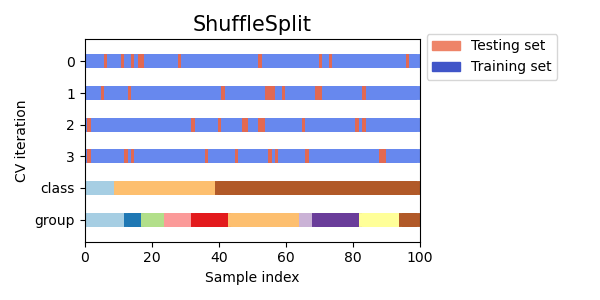

Попробуем применить к нашему датасету.

In [ ]:
model = RandomForestClassifier()
shuffle_split = ShuffleSplit(
    n_splits=5,       # Количество итераций перемешивания с разбиением на train и test
    test_size=0.1,    # Доля объектов, которые хотим класть в test на каждой итерации
    random_state=RANDOM_STATE,  # Фиксируем случайность
)
scores = cross_val_score(
    estimator=model,    # Модель, качество которой хотим оценить
    X=X_cards,          # Данные для обучения (не содержат целевую переменную)
    y=y_cards,          # Значения целевой переменной
    cv=shuffle_split,   # Стратегия кросс-валидации
    # Метрика качества, она будет максимизироваться
    scoring=metrics.make_scorer(metrics.fbeta_score, beta=2),
    n_jobs=N_JOBS,      # Количество ядер для вычислений, -1 - использование всех ядер
)
print(f'Значения f2-меры на разных фолдах: {scores.round(3)}')
print(f'Среднее f2-меры: {scores.mean():.3f}')

Значения f2-меры на разных фолдах: [0.795 0.845 0.85  0.813 0.789]
Среднее f2-меры: 0.819


Итак, с помощью `ShuffleSplit` мы увеличили размер train части, что дало ощутимый прирост качества. В то же время количество итераций кросс-валидации осталось таким же, то есть время работы не увеличилось. Но стоит также отметить, что из-за увеличения train части, test часть уменьшилась, следовательно увеличился разброс значений метрики на каждом фолде.

**Достоинства:**  
* Является хорошей альтернативой KFold, так как дает более четкий контроль над количеством итераций и разбиением на train и test. В KFold соотношение между размерами train и test жестко связано с количеством итераций.
* Результат разбиения случаен, поэтому не зависит от порядка объектов в данных.
* Позволяет выполнить большее количество итераций, чем KFold, что может быть полезно для более стабильной оценки качества.

**Недостатки:**  
* На некоторых итерациях распределение целевой переменной в обучающей и тестовой выборке может быть слишком разным, так как разбиение случайно.
* Не учитывает разбиение объектов на группы.
* Некоторые объекты могут не попасть ни в одну тестовую выборку, другие могут быть использованы многократно.

**Замечание.** Ключевым отличием KFold от ShuffleSplit является тот факт, что в KFold каждый объект выборки в одной из итераций попадает в тестовый фолд, а в остальных итерациях используется для обучения. В ShuffleSplit разбиение каждой итерации не зависит от предыдущих итераций, объект выборки может попасть как несколько раз в тестовые фолды, так и вовсе не попасть ни разу.

### 2.3. Stratified k-Fold Cross Validation

Как мы уже отмечали выше `KFold` из sklearn не учитывает распределение целевой переменной. В некоторых задачах это может быть критично.

> **Например**:
> - В датасете мошеннических транзакций есть сильный дизбаланс классов, поэтому велика вероятность, что в разных фолдах будет сильно отличаться соотношение положительного класса;
> - Аналогичная проблема часто встречается в медицинских датасетах, связанных с классификацией редких заболеваний;
> - Любой небольшой датасет.

Таким образом при кросс-валидации объекты выборки из положительного класса могут просто не попасть в фолды для обучения или попасть в сильно меньшем количестве, чем во всем датасете. Для решения данной проблемы используется **Stratified KFold**. При таком подходе каждый фолд имеет примерно такое же распределение целевого класса, как и во всем датасете. Это нужно, т.к. мы хотим получить значение метрики, которая отражает *реальное* качество модели, а значение метрики сильно зависит от баланса классов.

> **Например**, модель, предсказывающая для всего класс $0$, будет иметь хорошее качество на множестве из таргетов $\left\{0, 0, 1, 0\right\}$, но плохое на $\left\{1, 1, 1, 0\right\}$. Сохраняя баланс классов, нам удастся получить значение метрики, которое более приближено к реальному качеству модели.

*Замечание.* Стратификация работает только для классификации.

Ниже представлена визуальная интерпретация Stratified KFold.

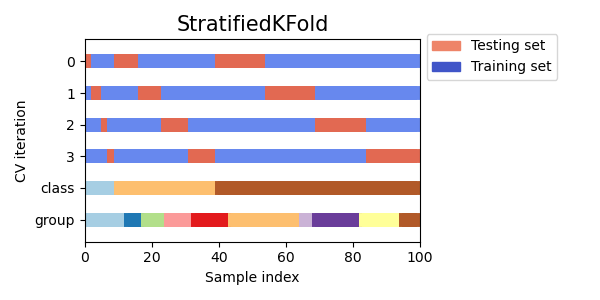

Для примера рассмотрим применение `Stratified KFold` на небольшом датасете, для задачи классификации ирисов. Построим графики распределения классов на каждой итерации на датасете Iris.

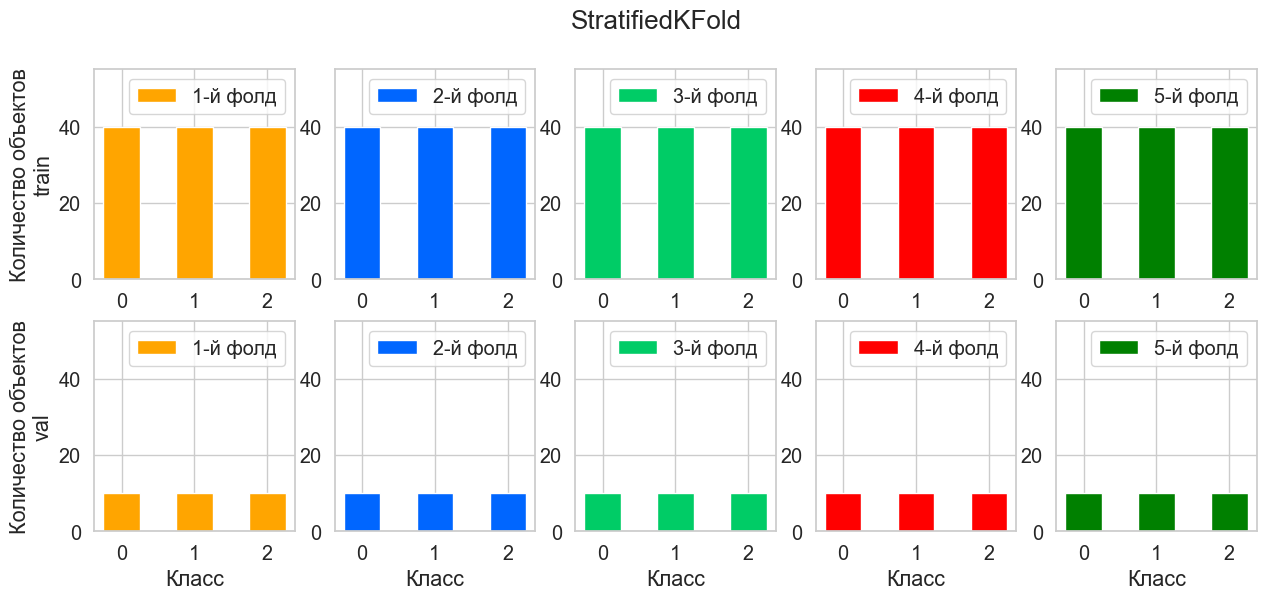

In [ ]:
n_splits = 5
stratified_kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

colors = ['orange', '#0066FF', '#00CC66', 'red', 'green']

plt.figure(figsize=(15, 6))
plt.suptitle('StratifiedKFold')
for i, (train_indexes, val_indexes) in enumerate(stratified_kfold.split(X_iris, y_iris)):
    for j, name, indexes in zip([0, 1], ['train', 'val'], [train_indexes, val_indexes]):
        plt.subplot(2, n_splits, n_splits * j + i + 1)
        values, counts = np.unique(y_iris[indexes], return_counts=True)
        plt.bar(values, counts, width=0.5, color=colors[i],
                label=f'{i + 1}-й фолд')
        plt.legend()
        plt.ylim(0, 55)
        plt.xticks([0, 1, 2])
        if j == 1:
            plt.xlabel('Класс')
        if i == 0:
            plt.ylabel(f'Количество объектов\n{name}')

plt.show()

И сравним с аналогичным графиком для обычного `KFold`.

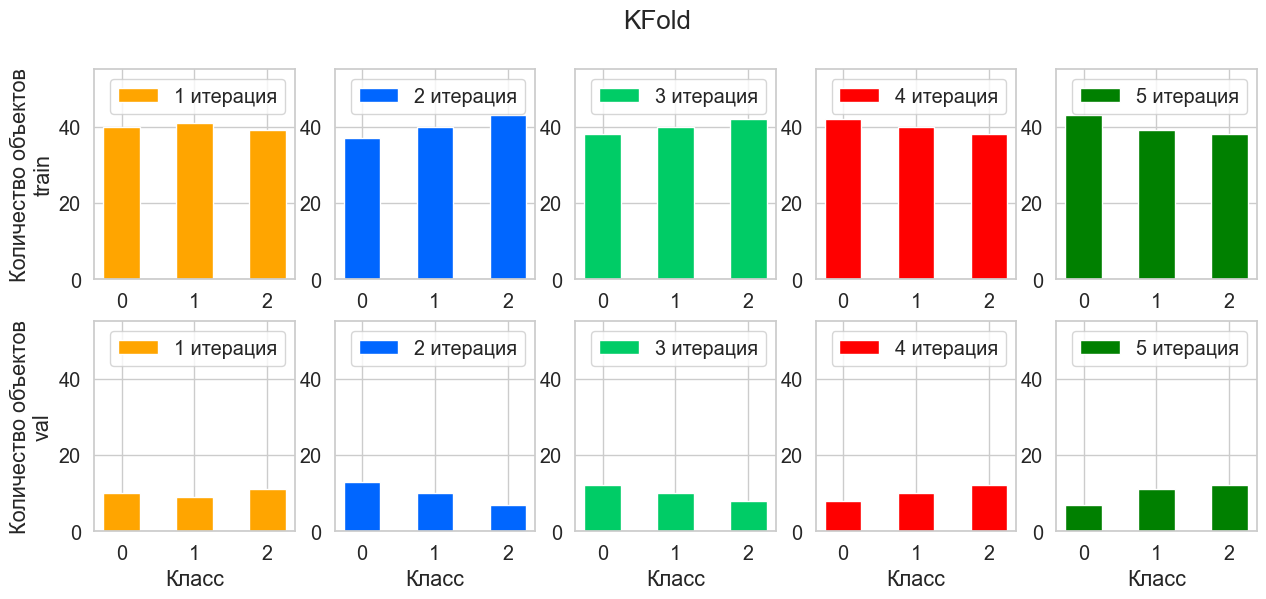

In [ ]:
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

colors = ['orange', '#0066FF', '#00CC66', 'red', 'green']

plt.figure(figsize=(15, 6))
plt.suptitle('KFold')
for i, (train_indexes, val_indexes) in enumerate(kfold.split(X_iris, y_iris)):
    for j, name, indexes in zip([0, 1], ['train', 'val'], [train_indexes, val_indexes]):
        plt.subplot(2, n_splits, n_splits * j + i + 1)
        values, counts = np.unique(y_iris[indexes], return_counts=True)
        plt.bar(values, counts, width=0.5, color=colors[i],
                label=f'{i + 1} итерация')
        plt.legend()
        plt.ylim(0, 55)
        plt.xticks([0, 1, 2])
        if j == 1:
            plt.xlabel('Класс')
        if i == 0:
            plt.ylabel(f'Количество объектов\n{name}')

plt.show()

В самом деле видим, что для части итераций распределение классов в валидации очень неравномерное, отличия в количестве некоторых классов более чем в 2 раза.

Теперь сравним `Stratified KFold` и `KFold` на датасете с дизбалансом классов, а именно классификации мошеннических транзакций. Визуализируем количество объектов положительного класса для каждого фолда.

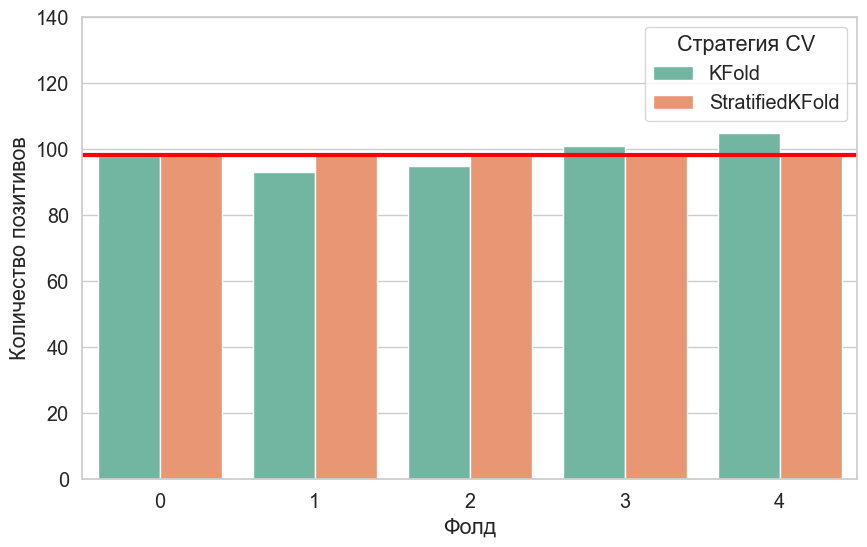

In [ ]:
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
stratified_kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

plt.figure(figsize=(10, 6))

cnt_positives = pd.DataFrame([], columns=['Стратегия CV', 'Фолд', 'Количество позитивов'])
for i, (train_indexes, val_indexes) in enumerate(kfold.split(X_cards, y_cards)):
    cnt = np.sum(y_cards.iloc[val_indexes])
    cnt_positives.loc[len(cnt_positives)] = ['KFold', i, cnt]

for i, (train_indexes, val_indexes) in enumerate(stratified_kfold.split(X_cards, y_cards)):
    cnt = np.sum(y_cards.iloc[val_indexes])
    cnt_positives.loc[len(cnt_positives)] = ['StratifiedKFold', i, cnt]

sns.barplot(cnt_positives, x='Фолд', y='Количество позитивов', hue='Стратегия CV')

plt.axhline(y=y_cards.sum() / n_splits, color='red', lw=3)

plt.ylim(0, 140)
plt.show()

Обучим случайный лес на этом датасете.

In [ ]:
stratified_kfold = StratifiedKFold(
    n_splits=5,          # Количество фолдов
    shuffle=True,        # Перемешиваем ли данные перед разбиением
    random_state=RANDOM_STATE,    # Фиксируем рандом, который появляется из-за shuffle
)
scores = cross_val_score(
    estimator=model,     # Модель, качество которой хотим оценить
    X=X_cards,           # Данные для обучения (не содержат целевую переменную)
    y=y_cards,           # Значения целевой переменной
    cv=stratified_kfold, # Стратегия кросс-валидации
    # Метрика качества, она будет максимизироваться
    scoring=metrics.make_scorer(metrics.fbeta_score, beta=2),
    n_jobs=N_JOBS,       # Количество ядер для вычислений, -1 - использование всех ядер
)
print(f'Значения f2-меры на разных фолдах: {scores.round(3)}')
print(f'Среднее f2-меры: {scores.mean():.3f}')

Значения f2-меры на разных фолдах: [0.805 0.819 0.833 0.807 0.803]
Среднее f2-меры: 0.814


Видим, что метрики по фолдам для датасета классификации транзакций стали сильно менее шумными: раньше был разброс от 0.774 до 0.923, а сейчас от 0.823 до 0.887.

Итак, в `Stratified KFold` при разбиении выборки на train и val на каждой итерации кросс-валидации распределение целевого класса остается примерно одинаковым.

**Достоинства:**  
* Оценивается качество модели, полученное при обучении на всех данных.  
* При подборе гиперпараметров можем контролировать переобучение, т.к. выбирается модель, показавшая лучшее качество на отложенных (тестовых) фолдах. Переобучение &mdash; это ситуация, когда модель показывает хорошее качество на обучающей выборке, но плохое качество на отложенной выборке.
* Учитывает распределение целевого класса при разбиении на обучающую и тестовую выборку.
* Особенно полезна для несбалансированных выборок, где некоторые классы представлены малым количеством объектов.
* Снижает дисперсию результатов по фолдам по сравнению с обычным `KFold`

**Недостатки:**  
* Значительная вычислительная сложность. Вместо одной процедуры обучения приходится обучать модель $k$ раз.
* Соотношение между train/test жестко связано с количеством итераций.
* Применима только для задач классификации или когда можно стратифицировать непрерывную целевую переменную
* Не учитывает разбиение объектов на группы (что это такое разберемся далее).


### 2.4. Stratified ShuffleSplit Cross Validation

Данная стратегия кросс-валидации делает то же самое, что и `Shuffle Split`, только учитывает распределение целевой переменной, как в `Stratified KFold`. Перед разбиением данные группируются по классам, и выборка для train и test формируется случайным образом внутри каждой группы. Благодаря этому в каждой итерации доли объектов разных классов в train и test совпадают с их долями во всём датасете. Такой подход сочетает случайность разбиения с сохранением репрезентативности распределения, что особенно важно при несбалансированных классах.

Пример работы:

In [ ]:
stratified_shuffle_split = StratifiedShuffleSplit(
    n_splits=5, test_size=0.2, random_state=RANDOM_STATE
)
data = np.arange(6)
targets = [0, 0, 1, 1, 1, 1]

for train_indexes, val_indexes in stratified_shuffle_split.split(data, targets):
    print(f'TRAIN: {train_indexes}, VAL: {val_indexes}')


TRAIN: [3 2 1 4], VAL: [5 0]
TRAIN: [5 3 0 2], VAL: [1 4]
TRAIN: [0 2 3 5], VAL: [1 4]
TRAIN: [0 4 3 2], VAL: [5 1]
TRAIN: [0 3 5 4], VAL: [1 2]


Визуальная интерпретация.

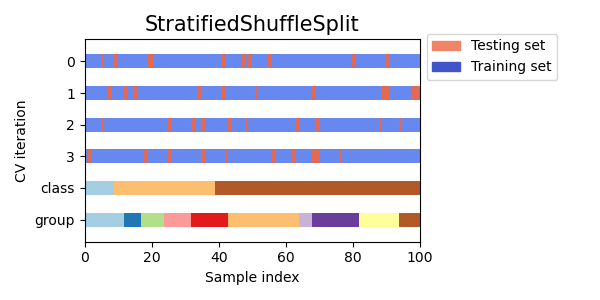

Сравним `Stratified Shuffle Split` и `Shuffle Split` на датасете ирисов.

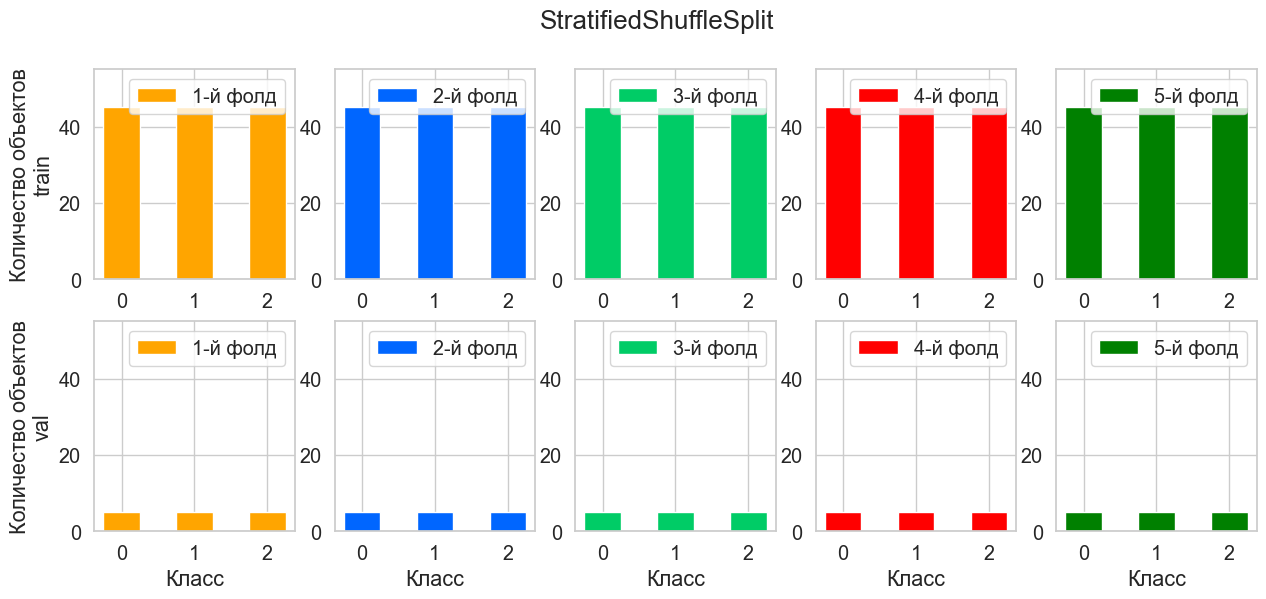

In [ ]:
n_splits = 5
stratified_shuffle_split = StratifiedShuffleSplit(
    n_splits=n_splits, test_size=0.1, random_state=RANDOM_STATE
)

colors = ['orange', '#0066FF', '#00CC66', 'red', 'green']

plt.figure(figsize=(15, 6))
plt.suptitle('StratifiedShuffleSplit')
for i, (train_indexes, val_indexes) in enumerate(stratified_shuffle_split.split(X_iris, y_iris)):
    for j, name, indexes in zip([0, 1], ['train', 'val'], [train_indexes, val_indexes]):
        plt.subplot(2, n_splits, n_splits * j + i + 1)
        values, counts = np.unique(y_iris[indexes], return_counts=True)
        plt.bar(values, counts, width=0.5, color=colors[i],
                label=f'{i + 1}-й фолд')
        plt.legend()
        plt.ylim(0, 55)
        plt.xticks([0, 1, 2])
        if j == 1:
            plt.xlabel('Класс')
        if i == 0:
            plt.ylabel(f'Количество объектов\n{name}')

plt.show()

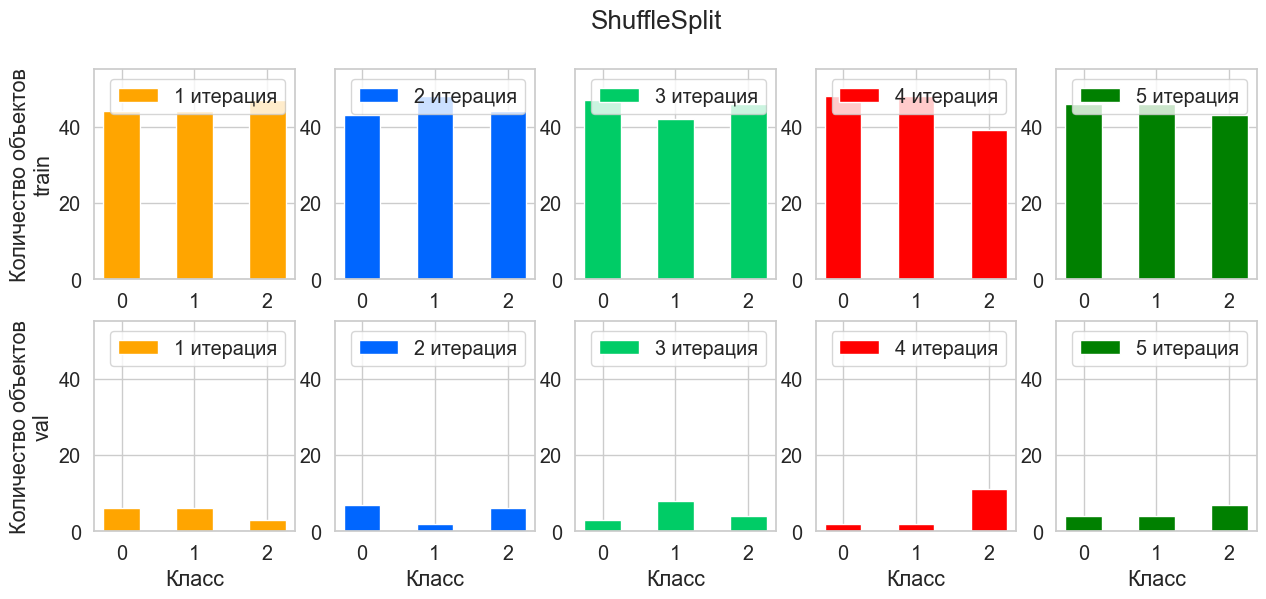

In [ ]:
n_splits = 5
shuffle_split = ShuffleSplit(n_splits=n_splits, test_size=0.1, random_state=RANDOM_STATE)

colors = ['orange', '#0066FF', '#00CC66', 'red', 'green']

plt.figure(figsize=(15, 6))
plt.suptitle('ShuffleSplit')
for i, (train_indexes, val_indexes) in enumerate(shuffle_split.split(X_iris, y_iris)):
    for j, name, indexes in zip([0, 1], ['train', 'val'], [train_indexes, val_indexes]):
        plt.subplot(2, n_splits, n_splits * j + i + 1)
        values, counts = np.unique(y_iris[indexes], return_counts=True)
        plt.bar(values, counts, width=0.5, color=colors[i],
                label=f'{i + 1} итерация')
        plt.legend()
        plt.ylim(0, 55)
        plt.xticks([0, 1, 2])
        if j == 1:
            plt.xlabel('Класс')
        if i == 0:
            plt.ylabel(f'Количество объектов\n{name}')

plt.show()

При размере тестовой выборки `test_size=0.1` разница между обычной и стратифицированной версией еще более заметна.

Теперь посмотрим на датасет транзакций.

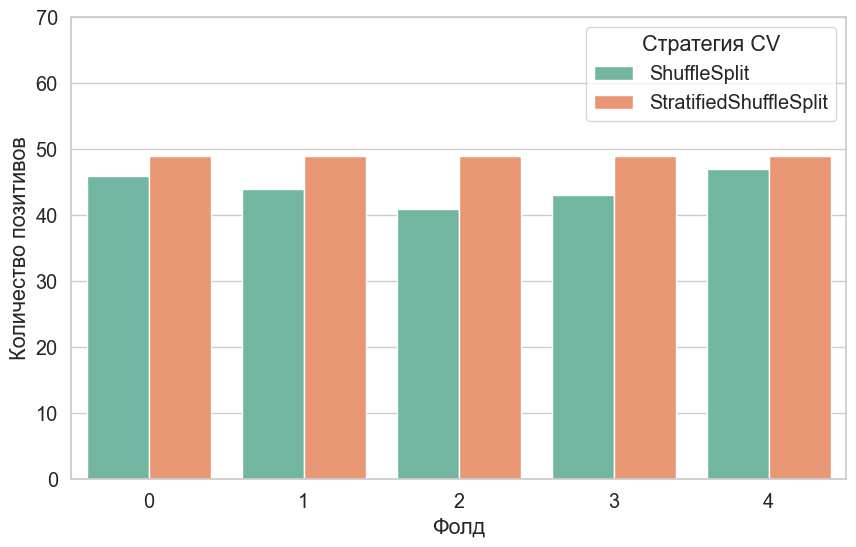

In [ ]:
n_splits = 5
shuffle_split = ShuffleSplit(n_splits=n_splits, test_size=0.1, random_state=RANDOM_STATE)
stratified_shuffle_split = StratifiedShuffleSplit(
    n_splits=n_splits, test_size=0.1, random_state=RANDOM_STATE
)

plt.figure(figsize=(10, 6))

cnt_positives = pd.DataFrame([], columns=['Стратегия CV', 'Фолд', 'Количество позитивов'])
for i, (train_indexes, val_indexes) in enumerate(shuffle_split.split(X_cards, y_cards)):
    cnt = np.sum(y_cards.iloc[val_indexes])
    cnt_positives.loc[len(cnt_positives)] = ['ShuffleSplit', i, cnt]

for i, (train_indexes, val_indexes) in enumerate(stratified_shuffle_split.split(X_cards, y_cards)):
    cnt = np.sum(y_cards.iloc[val_indexes])
    cnt_positives.loc[len(cnt_positives)] = ['StratifiedShuffleSplit', i, cnt]

sns.barplot(cnt_positives, x='Фолд', y='Количество позитивов', hue='Стратегия CV')

plt.axhline(y=y_cards.sum() / n_splits, color='red', lw=3)

plt.ylim(0, 70)
plt.show()

И обучим случайный лес.

In [ ]:
stratified_shuffle_split = StratifiedShuffleSplit(
    n_splits=5,         # Количество фолдов
    test_size=0.1,      # Доля объектов, которые хотим класть в test на каждой итерации
    random_state=RANDOM_STATE,    # Фиксируем рандом, который появляется из-за shuffle
)
scores = cross_val_score(
    estimator=model,    # Модель, качество которой хотим оценить
    X=X_cards,          # Данные для обучения (не содержат целевую переменную)
    y=y_cards,          # Значения целевой переменной
    cv=stratified_shuffle_split, # Стратегия кросс-валидации
    # Метрика качества, она будет максимизироваться
    scoring=metrics.make_scorer(metrics.fbeta_score, beta=2),
    n_jobs=N_JOBS,      # Количество ядер для вычислений, -1 - использование всех ядер
)
print(f'Значения f2-меры на разных фолдах: {scores.round(3)}')
print(f'Среднее f2-меры: {scores.mean():.3f}')

Значения f2-меры на разных фолдах: [0.823 0.854 0.858 0.766 0.748]
Среднее f2-меры: 0.810


**Достоинства:**  
* Является хорошей альтернативой Stratified KFold, так как дает более четкий контроль над количеством итераций и разбиением на train и test. В Stratified KFold соотношение между размерами train и test жестко связано с количеством итераций.
* Результат разбиения случаен, поэтому не зависит от порядка объектов в данных.
* Учитывает распределение целевого класса при разбиении на обучающую и тестовую выборку.
* Особенно полезна для несбалансированных выборок, где некоторые классы представлены малым количеством объектов.
* Снижает дисперсию результатов по фолдам по сравнению с обычным `ShuffleSplit`

**Недостатки:**  
* Значительная вычислительная сложность. Вместо одной процедуры обучения приходится обучать модель $k$ раз.
* Применима только для задач классификации или когда можно стратифицировать непрерывную целевую переменную
* Не учитывает разбиение объектов на группы (что это такое разберемся далее).


### 2.5. Group k-Fold Cross Validation

На практике могут возникнуть ситуации, когда в таблице появляется понятие **группы**. Это категориальная переменная, которая обладает свойством целостности. Что это означает? Понятнее всего будет показать на примере.
> **Пример 1**
>
> Представьте, что у вас есть данные с записями показателя уровня сахара в крови, причем на одного человека приходится по несколько записей. Вы хотите получить модель, которая сможет предсказывать уровень сахара на новых людях.
>
> Таким образом, при обучении модели нужно избегать ситуации, когда и в train, и в test попадают записи, соответствующие одному и тому же человеку. В данном примере **группой** записей является человек (например, его id).

> **Пример 2**
>
> Представьте, что вам нужно сделать поиск документов по запросу. Для этого требуется для каждой пары (запрос, документ) предсказывать релевантность документа данному запросу. Работать наша модель должна для любых запросов.
>
> В этом случае при обучении модели также нужно избегать ситуации, когда и в train, и в test попадают записи, соответствующие одному и тому же запросу. В данном примере **группой** записей является запрос.

Итак, в `Group KFold` разбиение на фолды происходит так, чтобы на каждой итерации в train или test не было представителей одной и той же группы. Другими словами, все представители одной группы попадают либо в train фолды, либо в test фолд.

Рассмотрим небольшой пример:

In [ ]:
data = np.arange(10)  # Какая-то выборка размера 10
groups = np.array([1, 1, 2, 2, 2, 2, 3, 3, 3, 3])

group_kfold = GroupKFold(n_splits=3)

for train_indexes, val_indexes in group_kfold.split(data, groups=groups):
    print(f'TRAIN: {train_indexes}, VAL: {val_indexes}')
    print(f'TRAIN groups: {groups[train_indexes]}, VAL groups: {groups[val_indexes]}')
    print()


TRAIN: [0 1 2 3 4 5], VAL: [6 7 8 9]
TRAIN groups: [1 1 2 2 2 2], VAL groups: [3 3 3 3]

TRAIN: [0 1 6 7 8 9], VAL: [2 3 4 5]
TRAIN groups: [1 1 3 3 3 3], VAL groups: [2 2 2 2]

TRAIN: [2 3 4 5 6 7 8 9], VAL: [0 1]
TRAIN groups: [2 2 2 2 3 3 3 3], VAL groups: [1 1]



Визуальная интерпретация.

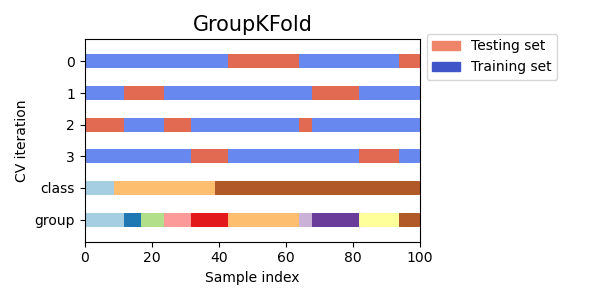

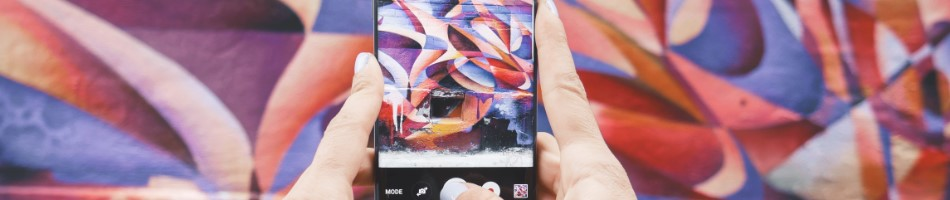

Рассмотрим датасет с kaggle [Human Activity Recognition with Smartphones](https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones). В нем решается задача предсказания типа активности человека по данным с датчиков акселерометра и гироскопа смартфона. Более подробно:

- **Типы активностей**:
  - **WALKING** – обычная ходьба по ровной поверхности
  - **WALKING\_UPSTAIRS** – движение по лестнице вверх,
  - **WALKING\_DOWNSTAIRS** – движение по лестнице вниз,
  - **SITTING** – состояние сидя,
  - **STANDING** – состояние стоя,
  - **LAYING** – лежачее положение.
- **Количество испытуемых**: 30
- **Признаки**: постобработка сигналов с датчиков акселерометра и гироскопа (ускорение и угловые скорости для трех различных осей), в итоге получилось 561 признак.

&#x2753; **Вопрос** &#x2753;

> Что является группой в данном примере?

<details>
 <summary> Кликни для показа ответа </summary>

 > Испытуемый. Испытуемых мало (всего 30), очевидно, что для одного и того же человека есть множество замеров с различными активностями. Поэтому важно, чтобы один и тот же испытуемый не попал в одновременно и в train, и в test.
</details><br/>

In [ ]:
# Скачиваем датасет из kaggle
path = kagglehub.dataset_download("uciml/human-activity-recognition-with-smartphones")
data_activity = pd.read_csv(os.path.join(path, 'train.csv'))
data_activity.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [ ]:
X_activity = data_activity.iloc[:, :-2]
subject = data_activity.iloc[:, -2]
y_activity = data_activity.iloc[:, -1]

Проверим есть ли дизбаланс по таргету или испытуемым.

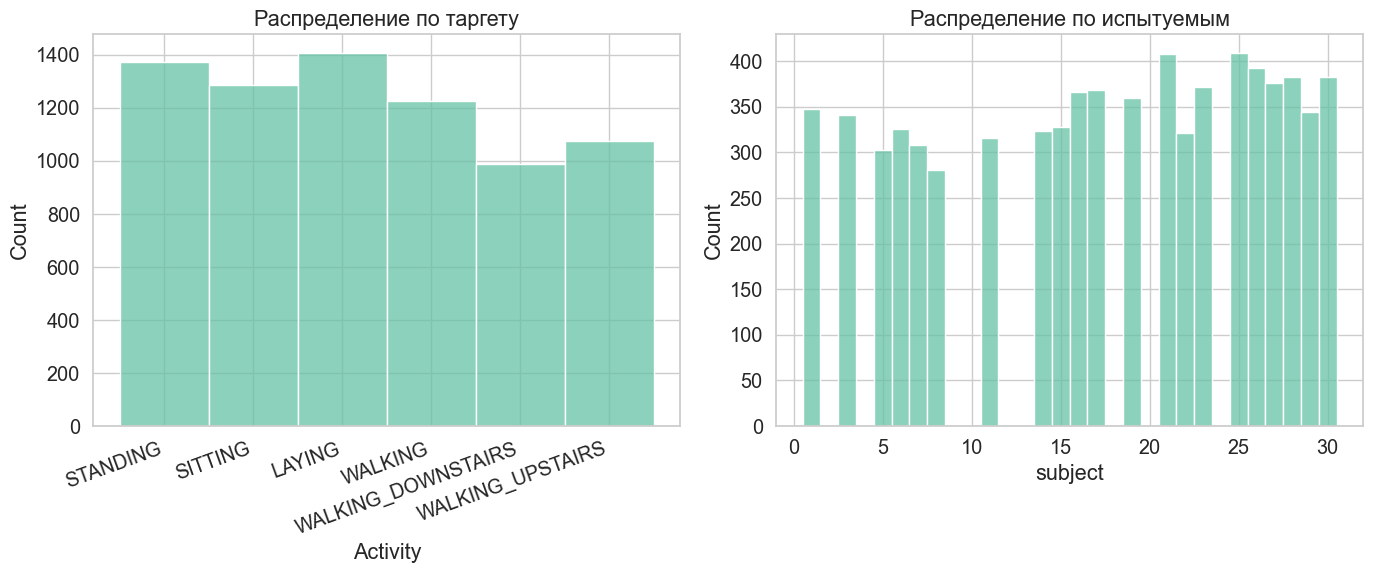

In [ ]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.title('Распределение по таргету')
sns.histplot(data_activity, x='Activity')
plt.xticks(rotation=20, ha='right')
plt.subplot(1, 2, 2)
plt.title('Распределение по испытуемым')
sns.histplot(data_activity, x='subject', discrete=True)

plt.tight_layout()
plt.show()

Видим, что дизбаланса нет. Часть испытуемых отсутствует, так как они попали в тестовую выборку на kaggle.

Обучим случайный лес с помощью обычного `KFold` и `Group KFold`, сравним насколько сильно утечка информации об испытуемом влияет на качество.

In [ ]:
kfold = KFold(
    n_splits=5,         # Количество фолдов
    shuffle=True,       # Перемешиваем ли данные перед разбиением
    random_state=RANDOM_STATE,    # Фиксируем рандом, который появляется из-за shuffle
)
scores = cross_val_score(
    estimator=model,    # Модель, качество которой хотим оценить
    X=X_activity,       # Данные для обучения (не содержат целевую переменную)
    y=y_activity,       # Значения целевой переменной
    cv=kfold,           # Стратегия кросс-валидации
    scoring='accuracy', # Метрика качества, она будет максимизироваться
    n_jobs=N_JOBS,      # Количество ядер для вычислений, -1 - использование всех ядер
)
print('Обычный KFold')
print(f'Значения точности на разных фолдах: {scores.round(3)}')
print(f'Средняя точность: {scores.mean():.3f}')

Обычный KFold
Значения точности на разных фолдах: [0.983 0.984 0.979 0.982 0.984]
Средняя точность: 0.982


In [ ]:
group_kfold = GroupKFold(
    n_splits=5,         # Количество фолдов
    shuffle=True,       # Перемешиваем ли данные перед разбиением
    random_state=RANDOM_STATE,    # Фиксируем рандом, который появляется из-за shuffle
)
scores = cross_val_score(
    estimator=model,    # Модель, качество которой хотим оценить
    X=X_activity,       # Данные для обучения (не содержат целевую переменную)
    y=y_activity,       # Значения целевой переменной
    groups=subject,     # Группа для каждого примера из X, y
    cv=group_kfold,     # Стратегия кросс-валидации
    scoring='accuracy', # Метрика качества, она будет максимизироваться
    n_jobs=N_JOBS,      # Количество ядер для вычислений, -1 - использование всех ядер
)
print('Group KFold')
print(f'Значения точности на разных фолдах: {scores.round(3)}')
print(f'Средняя точность: {scores.mean():.3f}')

Group KFold
Значения точности на разных фолдах: [0.929 0.882 0.896 0.852 0.962]
Средняя точность: 0.904


Как видно значения точности отличаются очень сильно. В случае обычного KFold из-за утечки информации об испытуемых ошибка в 4.5 раза меньше (0.02 vs 0.094), чем при правильном сплите с учетом групп. На практике, конечно же, мы бы хотели, чтобы наша модель работала и на других людях, поэтому при неправильной стратегии кросс-валидации были бы сильно лучшего мнения о полученной модели.

**Достоинства:**  
* Оценивается качество модели, полученное при обучении на всех данных.  
* Учитывает принадлежность объектов к группам, гарантируя, что объекты из одной группы не разделяются между обучающей и тестовой выборками. Это позволяет корректно оценивать качество модели при наличии зависимостей между объектами одной группы, предотвращая утечку информации.

**Недостатки:**
* Соотношение между train/test жестко связано с количеством итераций.
* Никак не учитывает распределение значений целевой переменной.
* Не подходит для ситуаций, когда группировка не имеет значения для задачи.

### 2.6. Group ShuffleSplit Cross Validation

В данной стратегии на каждой итерации данные разбиваются на train и test случайным образом, но так, чтобы представители одной группы не попадали одновременно и в train, и в test.

Рассмотрим небольшой пример.

In [ ]:
data = np.arange(8)
groups = np.array([1, 1, 2, 2, 3, 3, 4, 4])

group_shuffle_split = GroupShuffleSplit(n_splits=4, test_size=0.5, random_state=RANDOM_STATE)

for train_indexes, val_indexes in group_shuffle_split.split(data, groups=groups):
    print(f'TRAIN: {train_indexes}, VAL: {val_indexes}')
    print(f'TRAIN groups: {groups[train_indexes]}, VAL groups: {groups[val_indexes]}')
    print()


TRAIN: [0 1 4 5], VAL: [2 3 6 7]
TRAIN groups: [1 1 3 3], VAL groups: [2 2 4 4]

TRAIN: [0 1 4 5], VAL: [2 3 6 7]
TRAIN groups: [1 1 3 3], VAL groups: [2 2 4 4]

TRAIN: [2 3 4 5], VAL: [0 1 6 7]
TRAIN groups: [2 2 3 3], VAL groups: [1 1 4 4]

TRAIN: [4 5 6 7], VAL: [0 1 2 3]
TRAIN groups: [3 3 4 4], VAL groups: [1 1 2 2]



Визуальная интерпретация.

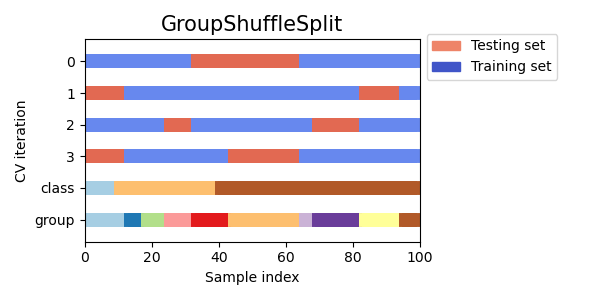

&#x2753; **Вопрос** &#x2753;

> Существует ли `Stratified Group Suffle Split`? Всегда ли он будет удачным?

<details>
 <summary> Кликни для показа ответа </summary>

 > Теоретически мы можем попытаться так объединять группы, чтобы получилось разбиение наиболее близкое к стратифицированному, но не всегда нам это удастся хорошо сделать. На рисунке выше как раз приведен пример, когда `Stratified Group Suffle Split` сделать совсем не получится: все объекты первого (голубого) класса лежат в одной группе, поэтому для любого разбиения их совсем не будет либо в тренировочной, либо в тестовой выборках, а значит ни о какой стратифицированности речи быть не может.
</details><br/>


Сравним ShuffleSplit и Group ShuffleSplit.

In [ ]:
shuffle_split = ShuffleSplit(
    n_splits=5,         # Количество фолдов
    test_size=0.1,      # Доля объектов, которые хотим класть в test на каждой итерации
    random_state=RANDOM_STATE,    # Фиксируем рандом, который появляется из-за shuffle
)
scores = cross_val_score(
    estimator=model,    # Модель, качество которой хотим оценить
    X=X_activity,       # Данные для обучения (не содержат целевую переменную)
    y=y_activity,       # Значения целевой переменной
    cv=shuffle_split,   # Стратегия кросс-валидации
    scoring='accuracy', # Метрика качества, она будет максимизироваться
    n_jobs=N_JOBS,      # Количество ядер для вычислений, -1 - использование всех ядер
)
print('Обычный ShuffleSplit')
print(f'Значения точности на разных фолдах: {scores.round(3)}')
print(f'Средняя точность: {scores.mean():.3f}')

Обычный ShuffleSplit
Значения точности на разных фолдах: [0.976 0.99  0.982 0.985 0.977]
Средняя точность: 0.982


In [ ]:
group_shuffle_split = GroupShuffleSplit(
    n_splits=5,         # Количество фолдов
    test_size=0.1,      # Доля объектов, которые хотим класть в test на каждой итерации
    random_state=RANDOM_STATE,    # Фиксируем рандом, который появляется из-за shuffle
)
scores = cross_val_score(
    estimator=model,    # Модель, качество которой хотим оценить
    X=X_activity,       # Данные для обучения (не содержат целевую переменную)
    y=y_activity,       # Значения целевой переменной
    groups=subject,     # Группа для каждого примера из X, y
    cv=group_shuffle_split, # Стратегия кросс-валидации
    scoring='accuracy', # Метрика качества, она будет максимизироваться
    n_jobs=N_JOBS,      # Количество ядер для вычислений, -1 - использование всех ядер
)
print('Group ShuffleSplit')
print(f'Значения точности на разных фолдах: {scores.round(3)}')
print(f'Средняя точность: {scores.mean():.3f}')

Group ShuffleSplit
Значения точности на разных фолдах: [0.919 0.971 0.952 0.923 0.908]
Средняя точность: 0.935


Всё полностью аналогично `KFold`: в случае обычного `ShuffleSplit` получаем сильно завышенные значения метрики из-за утечки информации об испытуемом.

**Достоинства:**  
* Является хорошей альтернативой `Group KFold`, так как дает более четкий контроль над количеством итераций и разбиением на train и test. В `KFold` соотношение между размерами train и test жестко связано с количеством итераций.
* Позволяет выполнить большее количество итераций, чем `Group KFold`, что может быть полезно для более стабильной оценки качества.
* Учитывает принадлежность объектов к группам, гарантируя, что объекты из одной группы не разделяются между обучающей и тестовой выборками. Это позволяет корректно оценивать качество модели при наличии зависимостей между объектами одной группы, предотвращая утечку информации.

**Недостатки:**
* Некоторые группы могут не попасть ни в одну тестовую выборку, другие могут быть использованы многократно.
* Соотношение между train/test жестко связано с количеством итераций.
* Никак не учитывает распределение значений целевой переменной.
* Не подходит для ситуаций, когда группировка не имеет значения для задачи.


**Вывод**

Итак, выше мы рассмотрели множество стратегий кросс-валидации и узнали, в каких случаях какой из них отдавать предпочтение.

Кросс-валидация &mdash; это отличный метод для оценки качества вашей модели, потому что при обучении вы можете задействовать все имеющиеся данные. К сожалению, его немаловажным минусом является количество процедур обучения, так как часто требуется большое количество вычислительных мощностей, особенно если вы работаете с большими датасетами.

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока